In [1]:
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

%matplotlib inline

LABEL1 = "Geant4-DNA (SBS, 10.6.ref-5)"
LABEL2 = "Geant4-DNA (IRT, 10.6.ref-5)"

#-------------------------------------------------------------------------------
def plot(mtype, title, df1, df2, pdf):
  ax = df1.plot(x = "time", y = mtype, logx = True, linewidth = 3.0,
                title = title, label = LABEL1) 
  df2.plot(kind = "scatter", x = "time", y = mtype, ax = ax, 
           color = "r", label = LABEL2, grid = True)
  ax.set_xlabel("Time (ps)")
  ax.set_ylabel("G-value")
  pdf.savefig()

#-------------------------------------------------------------------------------
def get_title(mkind):
  title = {"e_aq": "$\mathrm{e}_{\mathrm{aq}}^{-}$",
           "H3Op": "$\mathrm{H}_3\mathrm{O}^{+}$",
           "OH"  : "$^{\cdot}\mathrm{OH}$",
           "OHm" : "$\mathrm{OH}^{-}$",
           "H2"  : "$\mathrm{H}_2$",
           "H2O2": "$\mathrm{H}_2\mathrm{O}_2$",
           "H"   : "$\mathrm{H}^{\cdot}$",
           "O"   : "$\mathrm{O(3P)}$",
           "Om"  : "$\mathrm{O}^{\cdot-}$",
           "O2"  : "$\mathrm{O}_2$",
           "O2m" : "$\mathrm{O}_2^{-}$",
           "O3"  : "$\mathrm{O}_3$",
           "O3m" : "$\mathrm{O}_3^{-}$",
           "HO2" : "$\mathrm{HO}_2^{\cdot}$",
           "HO2m": "$\mathrm{HO}_2^{\cdot-}$"}
  return title[mkind]

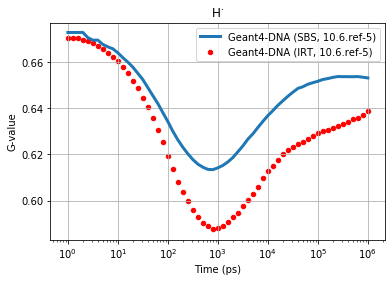

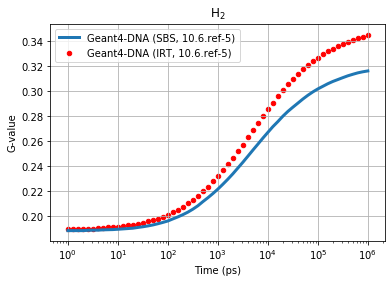

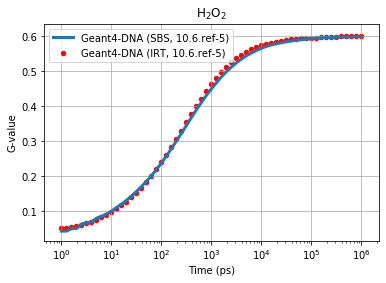

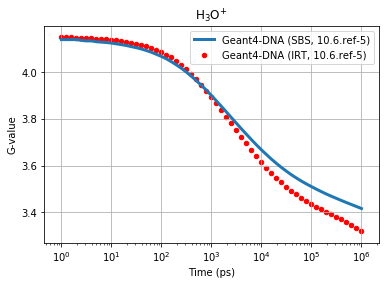

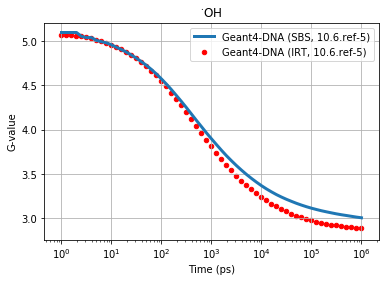

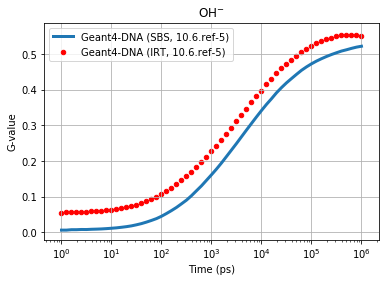

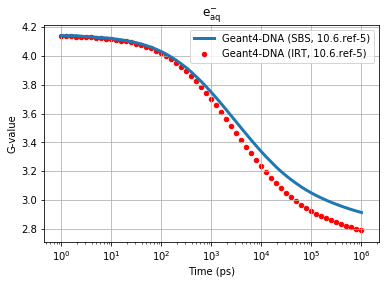

In [2]:
# read pickle files
df1 = pd.read_pickle("./G4DNA/gval.pkl") 
df2 = pd.read_pickle("gval.pkl")

with PdfPages('gval.pdf') as pdf:
  for mkind in df2.columns:
    if mkind == "time":
      continue
    if mkind in df1.columns:
      title = get_title(mkind)
      plot(mkind, title, df1, df2, pdf)